## 01_line_chart_styles.ipynb

In [84]:
import pandas as pd
import sqlite3

In [85]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

## Create exactly the same graph as the one below, including both values and style.

In [86]:
query_views = """
    SELECT date(datetime) AS date, COUNT(*) AS views
    FROM pageviews
    WHERE uid LIKE 'user_%'
    GROUP BY date(datetime)
    """
views_df = pd.read_sql(query_views, conn, parse_dates=['date'])

query_commits = """
    SELECT date(timestamp) AS date, COUNT(*) AS commits
    FROM checker
    WHERE uid LIKE 'user_%'
    GROUP BY date(timestamp)
    """

commits_df = pd.read_sql(query_commits, conn, parse_dates=['date'])

In [87]:
data = views_df.merge(commits_df, on='date', how='inner')
data = data.set_index('date').sort_index()
data

,views,commits
date,,
2020-04-17,1,23
2020-04-18,23,69
2020-04-19,15,33
2020-04-21,3,25
2020-04-22,1,28
2020-04-23,5,43
2020-04-25,1,104
2020-04-26,8,261
2020-04-28,2,5


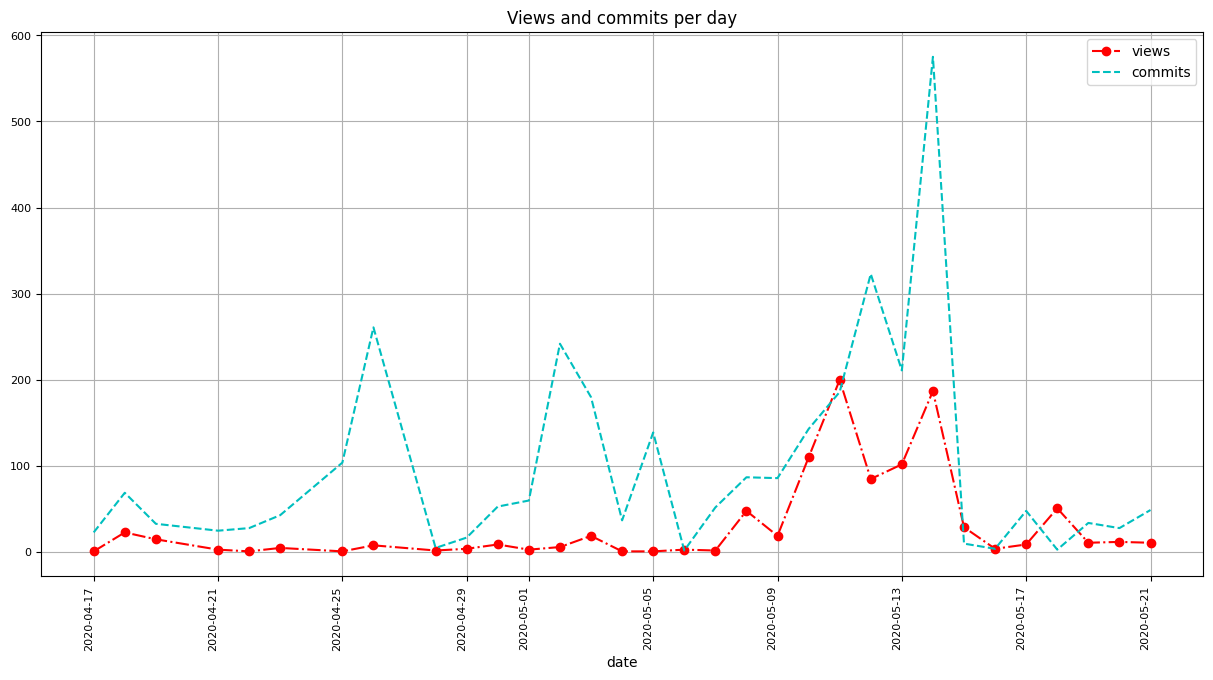

In [88]:
plot = data.plot(
    fontsize=8,
    figsize=(15,8),
    title='Views and commits per day',
    style=['ro-.', 'c--'],
    grid=True,
    rot=90
)

In [89]:
conn.close()

## How many times was the number of views larger than 150?

In [90]:
answer = (data['views'] > 150).sum()
print (f"The answer is {answer}")

The answer is 2
